In [9]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

In [10]:
load_dotenv()



api_key = os.getenv("GROQ_API_KEY")

parent_llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=api_key
)

subgraph_llm = parent_llm 

In [11]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [12]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Bangla.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [13]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [14]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [15]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

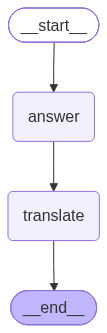

In [16]:
graph = parent_builder.compile()

graph

In [17]:
result = graph.invoke({'question': 'What is quantum physics'})

result["answer_hin"]

'**কোয়ান্টাম ফিজিক্স** (যাকে কোয়ান্টাম মেকানিক্স বা কোয়ান্টাম তত্ত্বও বলা হয়) হল পদার্থবিজ্ঞানের একটি শাখা, যা প্রকৃতির আচরণকে সবচেয়ে ক্ষুদ্র স্কেলে—সাধারণত পরমাণু, ইলেকট্রন, ফোটন এবং অন্যান্য উপ-পরমাণু কণার স্তরে—বর্ণনা করে।  \n\n### কেন ক্লাসিক্যাল ফিজিক্স যথেষ্ট নয়\n- **ক্লাসিক্যাল ফিজিক্স** (নিউটোনীয় মেকানিক্স, ম্যাক্সওয়েলের ইলেক্ট্রোম্যাগনেটিজম ইত্যাদি) দৈনন্দিন বস্তুগুলোর জন্য (গাড়ি, গ্রহ, বেসবল) চমৎকারভাবে কাজ করে—যেখানে অবস্থান, গতি, শক্তি ইত্যাদি নির্ভুলভাবে মাপা যায় এবং সেগুলো নির্ধারকভাবে আচরণ করে।  \n- যখন পরীক্ষায় বিলিয়ন গুণ ছোট কণাগুলো পরীক্ষা করা হয়, তখন এমন ঘটনাবলী প্রকাশ পায় যা **ক্লাসিক্যাল ধারণা দিয়ে ব্যাখ্যা করা যায় না**।  \n\n### কোয়ান্টাম ফিজিক্সের মূল নীতিমালা\n\n| নীতি | অর্থ | উদাহরণ |\n|------|------|--------|\n| **কোয়ান্টাইজেশন** | কিছু শারীরিক বৈশিষ্ট্য (শক্তি, কৌণিক ভর, বৈদ্যুতিক চার্জ) কেবল নির্দিষ্ট “কোয়ান্টা” আকারের অংশে থাকতে পারে। | হাইড্রোজেন পরমাণুতে বাঁধা একটি ইলেকট্রন শুধুমাত্র নির্দিষ্ট শক্তি স্তরে থাকতে পারে; তাকে অন্য স্তরে যা